# Lab 9

Description of lab:

Understand the assumptions and relative importance of the main 6 assumptions of regression analysis. Understand the inferential and predictive uncertainty. Evaluate validity through residual vs. fitted plots. Evaluate the appropriateness of a model through posterior predictive checks. Overfitting and use of AIC (Akaiki Information Criteria).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as spt

import statsmodels as sms
import statsmodels.formula.api as smf
import seaborn as sns

from cycler import cycler

plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams["axes.labelsize"]= 12
plt.rcParams["figure.facecolor"] = "#f2f2f2"
#plt.rcParams['figure.savefig.dpi'] = 100
plt.rcParams['savefig.edgecolor'] = "#f2f2f2"
plt.rcParams['savefig.facecolor'] ="#f2f2f2"
plt.rcParams["figure.figsize"] = [16,10]
plt.rcParams['savefig.bbox'] = "tight"
plt.rcParams['font.size'] = 14
greens = ['#66c2a4','#41ae76','#238b45','#006d2c','#00441b']
multi =['#66c2a4','#1f78b4','#a6cee3','#b2df8a','#33a02c','#fb9a99','#e31a1c','#fdbf6f']
plt.rcParams["axes.prop_cycle"] = cycler(color=multi)

In [2]:
pv = pd.read_csv("https://jmaurit.github.io/anv_statistikk/data/pv_csi_new.csv", index_col=0)

In [3]:
# Prepping the data:
pv['date'] = pd.to_datetime(pv['date'], format = '%Y-%m-%d')
pv = pv.sort_values(by = ['date'], ascending = True)
pv['time_days_m'] = pv['time_days'] - np.mean(pv['time_days'])
pv['time_days_m_sq'] = pv['time_days_m'] ** 2

In [7]:
mod1 = smf.ols('cost_per_kw ~ time_days_m + time_days_m_sq', data = pv).fit()
mod1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            cost_per_kw   R-squared:                       0.335
Model:                            OLS   Adj. R-squared:                  0.335
Method:                 Least Squares   F-statistic:                 2.688e+04
Date:                Mon, 04 Dec 2023   Prob (F-statistic):               0.00
Time:                        15:17:10   Log-Likelihood:            -9.4162e+05
No. Observations:              106551   AIC:                         1.883e+06
Df Residuals:                  106548   BIC:                         1.883e+06
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept       6290.8428      6.985    900.577      0.000    6277.152    6304.534
time_days_m       -1.9218      0.009   -215.208      0.000      -1.939      -1.904
time_days_m_sq    -0.0003   1.14e-05    -24.333      0.000      -0.000      -0.000
==============================================================================
Omnibus:                   165044.969   Durbin-Watson:                   1.873
Prob(Omnibus):                  0.000   Jarque-Bera (JB):        591611598.739
Skew:                           9.087   Prob(JB):                         0.00
Kurtosis:                     367.591   Cond. No.                     8.99e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 8.99e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [5]:
import datetime
T = (pv['date'].iloc[-1] - pv['date'].iloc[0]).days + 1

base = pv['date'].iloc[0]
date_list = [base + datetime.timedelta(days = x) for x in range(T)]
fake_dates = pd.to_datetime(pd.Series([date.strftime('%Y-%m-%d') for date in date_list]))

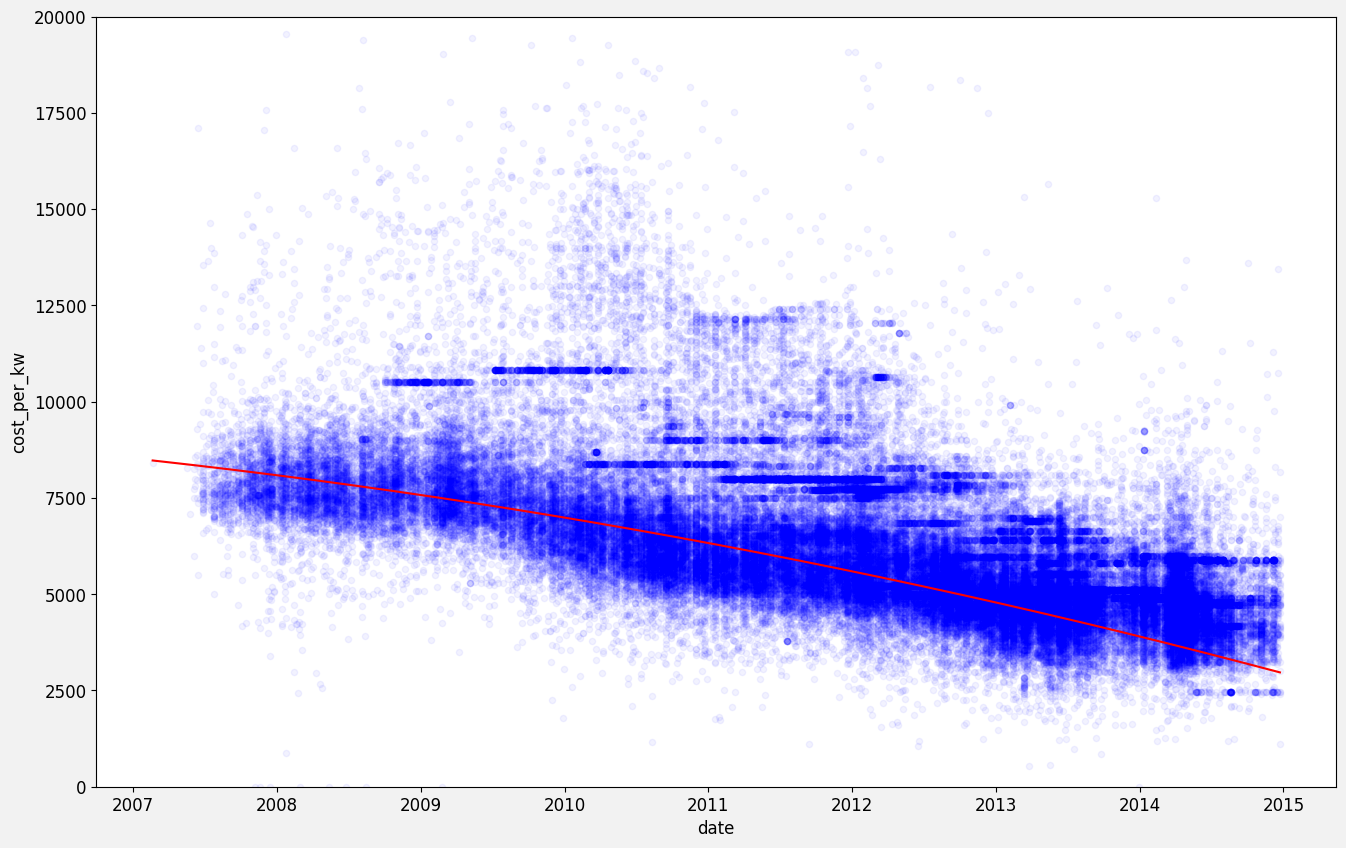

In [8]:
# Visualizing the model:
b0_hat = mod1.params.iloc[0]
b1_hat = mod1.params.iloc[1]
b2_hat = mod1.params.iloc[2]

x_line = np.linspace(0, T, T)
x_line_m = x_line - np.mean(x_line)
y_line = b0_hat + b1_hat * x_line_m + b2_hat * x_line_m ** 2

fig, ax = plt.subplots()
pv.plot.scatter('date', 'cost_per_kw', alpha = .05, color = 'blue', ax = ax)
ax.set_ylim(0, 20000)
ax.plot(fake_dates, y_line, color = 'red')
plt.show()

In [9]:
# Simulation to generate and draw the uncertainty:
df = mod1.df_resid
sigma_hat = np.sqrt(mod1.mse_resid)
bs_vcov = mod1.cov_params(scale = 1)
bs = mod1.params
bs_vcov

,Intercept,time_days_m,time_days_m_sq
Intercept,1.757302e-05,-7.169207e-09,-1.957946e-11
time_days_m,-7.169207e-09,2.871991e-11,1.714360e-14
time_days_m_sq,-1.957946e-11,1.714360e-14,4.682003e-17


##### A bit about the covariance-variance matrix and where coefficient standard errors come from (a bit technical)

In [16]:
# Coefficient standard errors that are reported in the regression output (scaled cov-var matrix):
vcov_scaled = sigma_hat ** 2 * bs_vcov
vcov_scaled

,Intercept,time_days_m,time_days_m_sq
Intercept,48.795076,-1.990676e-02,-5.436635e-05
time_days_m,-0.019907,7.974667e-05,4.760270e-08
time_days_m_sq,-0.000054,4.760270e-08,1.300053e-10


In [15]:
# Same as directly from the model:
mod1.cov_params()

,Intercept,time_days_m,time_days_m_sq
Intercept,48.795076,-1.990676e-02,-5.436635e-05
time_days_m,-0.019907,7.974667e-05,4.760270e-08
time_days_m_sq,-0.000054,4.760270e-08,1.300053e-10


In [17]:
# Extract the variance component from the diagonal corresponding to time_days_m:
vcov_scaled.iloc[1, 1]

7.974667228185018e-05

In [18]:
# Calculate the standard error for just the linear term of the time trend:
np.sqrt(vcov_scaled.iloc[1, 1])

0.008930099231355168

##### Simulating from a regression output